In [48]:
# importar pandas y visualizar la version
import pandas as pd

print(pd.__version__)

3.0.5


In [49]:
# validar en que carpeta esta trabajando el notebook
import os

print(os.getcwd())

c:\Users\larau\Mineria_Datos_UMB\notebooks


In [50]:
# comprobar las hojas de calculo que hay en el libro de excel
archivo = "../datasets/salarios_experiencia4 (1).xlsx"

excel = pd.ExcelFile(archivo)

print(excel.sheet_names)

['dataset', 'train', 'test', 'README']


In [51]:
# crear dataframe a partir de la hoja de calculo dataset, validar que si lee los datos
df = pd.read_excel(archivo, sheet_name="dataset")
df.head()

,A,S
0,19.35,15330000
1,10.97,9000000
2,21.46,16520000
3,17.43,13630000
4,2.35,3300000


In [52]:
# validar el tamaño del dataframe (rows, columns)
df.shape

(200, 2)

In [53]:
# identificar los nombres de las columnas del dataframe
df.columns

Index(['A', 'S'], dtype='str')

In [54]:
# Revisar el tipo de datos que maneja cada columna del dataframe
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       200 non-null    float64
 1   S       200 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.3 KB


In [55]:
# Visualizar los primeros 10 registros del dataframe para recitificar que los datos se leyeron correctamente y que no hay errores de lectura
df.head(10)


,A,S
0,19.35,15330000
1,10.97,9000000
2,21.46,16520000
3,17.43,13630000
4,2.35,3300000
5,24.39,19210000
6,19.03,14860000
7,19.65,15550000
8,3.20,2820000
9,11.26,9360000


In [56]:
df.tail(10)

,A,S
190,23.42,18090000
191,6.02,5950000
192,3.07,3770000
193,20.78,15410000
194,3.83,3140000
195,4.48,4660000
196,14.98,11780000
197,21.86,17010000
198,4.91,5250000
199,7.76,6990000


In [57]:
# Identificar los valores unicos de la columna A
# se identifca que cada valor equivalen a los años de experiencia laboral.
df["A"].head(20)

0     19.35
1     10.97
2     21.46
3     17.43
4      2.35
5     24.39
6     19.03
7     19.65
8      3.20
9     11.26
10     9.27
11    23.17
12    16.10
13    20.57
14    11.09
15     5.68
16    13.86
17     1.60
18    20.69
19    15.79
Name: A, dtype: float64

In [58]:
# conocer la distribucion de los datos
# count → confirmar los 200 registros
# mean → promedio
# std → dispersión
# min → menor experiencia/salario
# 25%, 50%, 75% → cuartiles
# max → mayor experiencia/salario
df.describe()

,A,S
count,200.000000,2.000000e+02
mean,12.347000,1.015060e+07
std,7.058002,5.044048e+06
min,0.180000,1.000000e+06
25%,6.305000,5.712500e+06
50%,11.975000,9.985000e+06
75%,18.682500,1.474000e+07
max,24.810000,1.928000e+07


In [59]:
# Observaciones:
# 1. La experiencia va de 0.18 a 24.81 años
# 2. El salario va de $1.000.000 a $19.280.000.
# 3. La desviación estándar de la experiencia es de 5.22 años y la del salario es de $4.14 millones.


In [60]:
# Preguntas de relacion: ¿Realmente existe una relación entre experiencia y salario?
# para responder a esta pregunta se inicia con una grafia para validar la correlación entre las variables, para esto se utiliza un diagrama de dispersión (scatter plot) y se calcula el coeficiente de correlación de Pearson.
# importar matplotlib para graficar
import matplotlib.pyplot as plt

Text(0, 0.5, 'Salario')

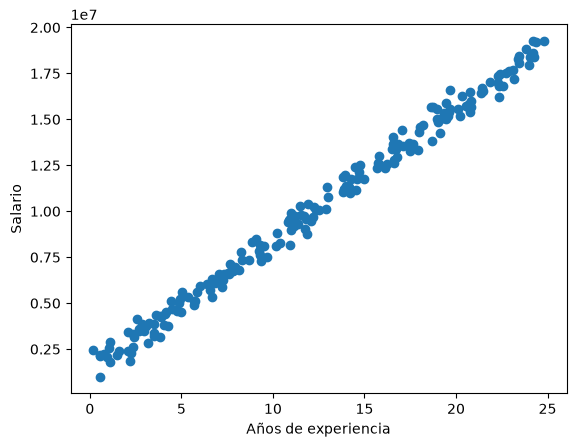

In [61]:
# crear diagrama de dispersión (scatter plot) para validar la correlación entre las variables
# df["A"] sera nuestro eje x y df["S"] sera nuestro eje y, por lo tanto cada fila del dataframe sera un punto en el diagrama de dispersión.
# en la grafica Sse ugiere que existe una relación positiva entre las dos variables
plt.scatter(df["A"], df["S"])
plt.xlabel("Años de experiencia")
plt.ylabel("Salario")


In [64]:
# duplicated() revisa cada fila y determina si esa fila ya apareció anteriormente.
df.duplicated().sum()

np.int64(0)

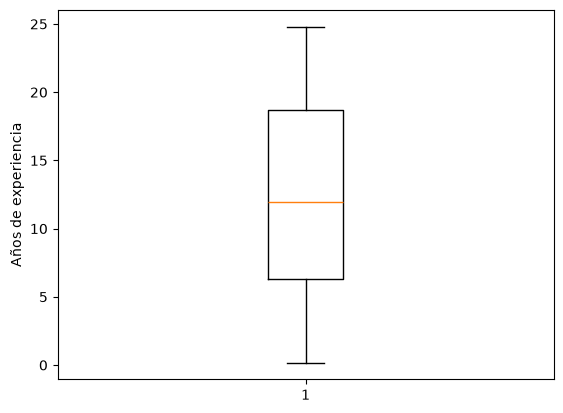

In [66]:
pregunta = "¿hay valores atipicos (outliers)?"
# Ejemplo Por ejemplo, imaginemos que alguien tiene 20 años de experiencia pero un salario extremadamente bajo comparado con todos los demás. Ese punto podría afectar nuestra regresión.
# boxplot() nos permite visualizar la distribución y detectar valores que podrían estar alejados del resto.
# los puntos que aparezcan fuera de los límites del boxplot serían los que debemos investigar como posibles outliers.
plt.boxplot(df["A"])
plt.ylabel("Años de experiencia")
plt.show()

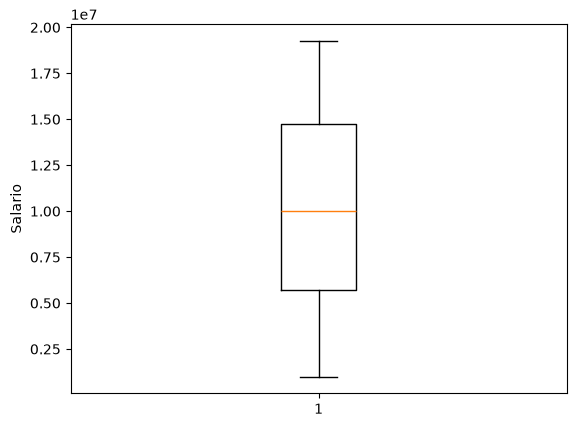

In [67]:
plt.boxplot(df["S"])
plt.ylabel("Salario")
plt.show()

In [68]:
"Revisión	Resultado"
"Registros	200"
"2Variables	2 (A, S)"
"Datos faltantes	0"
"Duplicados	0"
"Tipo de A	Numérico (float64)"
"Tipo de S	Numérico (int64)"
"Relación visual	Positiva y aproximadamente lineal"
# Outliers visibles	No

'Relación visual\tPositiva y aproximadamente lineal'

In [69]:
Pregunta = "¿existe una relación entre experiencia y salario?"
df["A"].corr(df["S"])

np.float64(0.9960055730509023)

In [70]:
Resultado = 0.996
"Existe una relación lineal positiva muy fuerte entre los años de experiencia y el salario en este dataset."

'Existe una relación lineal positiva muy fuerte entre los años de experiencia y el salario en este dataset.'

Text(0, 0.5, 'Cantidad de registros')

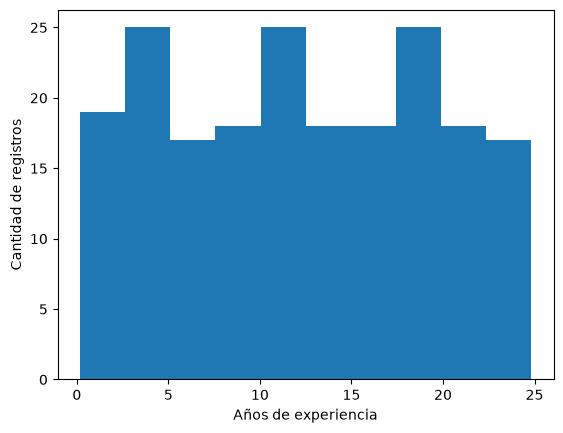

In [76]:
# Agrupa los valores de A en intervalos y cuenta cuántos registros caen dentro de cada intervalo.
# uso de hist(), el histograma mira una sola variable y nos dice cómo se reparten sus valores.
plt.hist(df["A"])
plt.xlabel("Años de experiencia")
plt.ylabel("Cantidad de registros")

In [78]:
Interpretacion= "La distribución de los años de experiencia presenta mayor concentración de registros en los intervalos de 3 a 5, 10 a 13 y 18 a 20 años. Esto indica que los datos no se distribuyen de manera uniforme a lo largo del rango de experiencia"

Text(0, 0.5, 'Cantidad de registros')

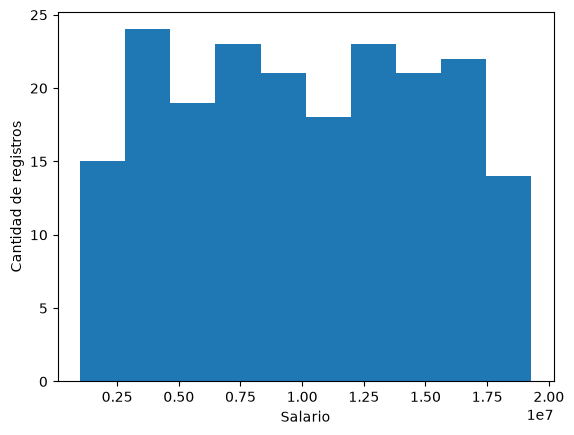

In [79]:
# Agrupa los valores de S en intervalos y cuenta cuántos registros caen dentro de cada intervalo.
# uso de hist(), el histograma mira una sola variable y nos dice cómo se reparten sus valores.
plt.hist(df["S"])
plt.xlabel("Salario")
plt.ylabel("Cantidad de registros")

In [81]:
Interpretacion= "La distribución de los salarios se encuentra relativamente repartida entre $1 millón y $19,28 millones. Se observan mayores concentraciones en algunos intervalos, especialmente alrededor de $3–5 millones, $6–8 millones y $12–14 millones. No se evidencia una concentración exclusiva en un único rango salarial."

In [82]:
# Defincion de variables para la regresion lineal
# A → años de experiencia → será nuestra variable independiente (X).
# S → salario → será nuestra variable dependiente (Y).
X = df[["A"]]
y = df["S"]

print(X.head())
print(y.head())

       A
0  19.35
1  10.97
2  21.46
3  17.43
4   2.35
0    15330000
1     9000000
2    16520000
3    13630000
4     3300000
Name: S, dtype: int64


In [84]:
"Interpretacion"
# X contiene los años de experiencia. Es lo que el modelo va a utilizar como información de entrada
# Y Contiene el salario que queremos que el modelo aprenda a predecir.

'Interpretacion'

In [88]:
# Dividir nuestros 200 registros en datos de entrenamiento y datos de prueba. 20%-30% datos de prueba y 70%-80% datos de entrenamiento.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Mostrar las (rows, columns) que se han generado para entrenamiento y prueba, las primeras dos filas son los datos de entrenamiento y las últimas dos filas son los datos de prueba. 
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 1)
(40, 1)
(160,)
(40,)


In [89]:
# Ahora vamos a utilizar LinearRegression de scikit-learn y crear el modelo de regresión lineal. Este modelo aprenderá la relación entre los años de experiencia y el salario a partir de los datos de entrenamiento.
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()

modelo.fit(X_train, y_train)
print("Pendiente:", modelo.coef_[0])
print("Intercepto:", modelo.intercept_)

# ecuaacion de la regresion lineal: S = mA + b 
# m = pendiente → modelo.coef_[0]
# b = intercepto → modelo.intercept_
#

Pendiente: 712206.8562406132
Intercepto: 1325224.113655081


In [90]:
"Interpretacion"
# S = modelo.coef_[0]A + modelo.intercept_
"Por cada 1 unidad que aumenta A, el modelo estima que S aumenta aproximadamente $712.207."
"Cuando A = 0, el modelo estima un valor de S de aproximadamente $1.325.224"


'Cuando A = 0, el modelo estima un valor de S de aproximadamente $1.325.224'

In [96]:
# ahora con los datos de prueba, vamos a predecir los salarios utilizando el modelo que acabamos de entrenar. Esto nos permitirá evaluar qué tan bien nuestro modelo generaliza a datos que no ha visto antes.
y_pred = modelo.predict(X_test)

print(y_pred)

# Crear tabla para comparar los valores reales de salario con los valores predichos por el modelo. Esto nos permitirá ver qué tan cerca están las predicciones del modelo de los valores reales.
comparacion = pd.DataFrame({
    'Real': y_test / 1_000_000,
    'Predicho': y_pred /1_000_000
})

print(comparacion.head(10))

[12549604.16800714  5370559.05710176 14586515.7768553  14266022.69154702
  3169839.87131827 16580694.97432902  9102522.98380258  6502967.95852434
  4259516.36136641 15654826.06121622 11281875.96389885 10562547.03909583
  7927381.67100556 11246265.62108682  7977236.15094241 18995076.21698469
  9494236.75473491  3825070.17905963 15818633.63815156  1873623.39296035
  2065919.24414532 11196411.14114998  9138133.32661461  8112555.45362812
 11182167.00402517 13226200.68143573  1731182.02171223  6737996.22108374
 10120978.78822665 11673589.73483119  9344673.31492439 16060783.96927337
 15227501.94747185  6332038.31302659 16039417.76358615 15191891.60465982
  1731182.02171223  9914438.79991688 11203533.20971238  6552822.43846118]
      Real   Predicho
95   12.60  12.549604
15    4.88   5.370559
30   15.67  14.586516
158  14.70  14.266023
128   4.13   3.169840
115  16.69  16.580695
69    9.60   9.102523
170   6.26   6.502968
174   4.39   4.259516
45   15.54  15.654826


In [101]:
"Evaluacion del modelo, metricas de medida de error"
# MAE — Error Absoluto Medio / preguntas como: ¿En promedio, cuánto se equivocó el modelo al predecir los salarios? ¿Qué tan lejos están las predicciones del modelo de los valores reales?
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("Error Absoluto Medio (MAE):", round(mae / 1_000_000, 2), "millones de pesos")
# El MAE no le da importancia a si el modelo se pasó o se quedó corto, solamente mide qué tan grande fue la diferencia.

Error Absoluto Medio (MAE): 0.36 millones de pesos


In [103]:
# MSE - Error Cuadrático Medio / eleva los errores al cuadrado, por lo que castiga mucho más los errores grandes.
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("Error Cuadrático Medio (MSE):", mse)
# MSE = n/1 ​∑(Real−Predicho)2  MSE eleva cada error al cuadrado antes de sacar el promedio

Error Cuadrático Medio (MSE): 209279714058.6037


In [105]:
# RMSE — Raíz del Error Cuadrático Medio / hace exactamente lo contrario: saca la raíz cuadrada del MSE.
from sklearn.metrics import mean_squared_error
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print("RMSE:", round(rmse / 1_000_000, 2), "millones de pesos")

RMSE: 0.46 millones de pesos


In [107]:
"Coeficiente de determinación"
# R² es una métrica que nos dice qué tan bien nuestro modelo se ajusta a los datos. Un valor de R² cercano a 1 indica un buen ajuste, mientras que un valor cercano a 0 indica un mal ajuste.
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R²:", round(r2, 4))
print("R² (%):", round(r2 * 100, 2), "%")

R²: 0.9902
R² (%): 99.02 %


In [109]:
Interpretacion= "El modelo de regresión lineal logra explicar aproximadamente el 99,02 % de la variabilidad de S utilizando A."
# A tiene una relación lineal muy fuerte con S en los datos que estamos utilizando para evaluar el modelo


| Métrica  |       Resultado | ¿Qué nos dice?                                            |
| -------- | --------------: | --------------------------------------------------------- |
| **MAE**  |         $0,36 M | Error promedio ≈ **$360.000**                             |
| **MSE**  | 209.279.714.059 | Penaliza especialmente errores grandes                    |
| **RMSE** |         $0,46 M | Error considerando más los errores grandes ≈ **$460.000** |
| **R²**   |     **99,02 %** | El modelo explica **99,02 %** de la variabilidad de `S`   |


In [117]:
"Proyeccion de los 5 próximos años"
# Para realizaer la proyeccion primero calculamos el intervalo promedio entre los periodos de A
intervalo_promedio = df['A'].sort_values().diff().mean()

print("Intervalo promedio:", round(intervalo_promedio, 4))

Intervalo promedio: 0.1238


In [119]:
# ahora vamos a vanzar 0.1238 unidades dentro de los 5 años proximos, para esto utilizamos la función np.arange() de la librería numpy, que nos permite generar un arreglo de valores equidistantes. En este caso, generamos un arreglo de 5 valores que representan los próximos 5 años, y luego sumamos el intervalo promedio a cada uno de esos valores para obtener los valores futuros de A.
import numpy as np

max_A = df['A'].max()

future_A = max_A + intervalo_promedio * np.arange(1, 6)

print("Valores futuros de A:")
print(future_A)

Valores futuros de A:
[24.93376884 25.05753769 25.18130653 25.30507538 25.42884422]


In [ ]:
# future_A.reshape(-1, 1) para convertirlo en una estructura de 5 filas × 1 columna, es decir:
predicciones_futuras = modelo.predict(future_A.reshape(-1, 1))

print("Predicciones futuras de S:")
print(predicciones_futuras)

Predicciones futuras de S:
[19083225.23642794 19171374.25587119 19259523.27531444 19347672.29475769
 19435821.31420093]


c:\Users\larau\Mineria_Datos_UMB\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Organizar los resultados de la proyección en un DataFrame para una mejor visualización. Esto nos permitirá ver claramente los valores futuros de A y sus correspondientes predicciones de S.
proyeccion = pd.DataFrame({
    'A futuro': future_A,
    'S estimado (millones)': predicciones_futuras / 1_000_000
})

print(proyeccion.round(2))

   A futuro  S estimado (millones)
0     24.93                  19.08
1     25.06                  19.17
2     25.18                  19.26
3     25.31                  19.35
4     25.43                  19.44
